In [1]:
##### Import #######

import random
import numpy as np
import asymmetree.treeevolve as te
import networkx as nx
import copy
import matplotlib.pyplot as plt
import itertools

from asymmetree.visualization.tree_vis import visualize, assign_colors
from insert_hybrid import insertHybrid
from bmg_fun import convert_to_nx
from MISC_Functions import visualize_BCN, visualize_bmg, visualize_network, visualize_easyBCN, contract_nodes
from bmg_Tony import bmg
from all_BCEA import BCEA1, BCEA2, BCEA3, BCEA4
from BICcherry_reverse import BICcherry_reverse
from simplifying_operations import greedy_search


In [2]:
def generateTree(seed:int = None, nSpecies:int = 2):

    if seed:
        # Setze den Seed für Pythons Standard-Zufallsfunktionen
        random.seed(seed)
        # Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
        np.random.seed(seed)
    speciesTree = te.species_tree_n_age(
        age = 1.0,
        n = nSpecies
        #, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
    )
    # gene tree
    T = te.dated_gene_tree(
        speciesTree, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
    )
    # prune all loss branches and the planted root
    geneTree = te.prune_losses(T)
    
    return speciesTree, geneTree

35450


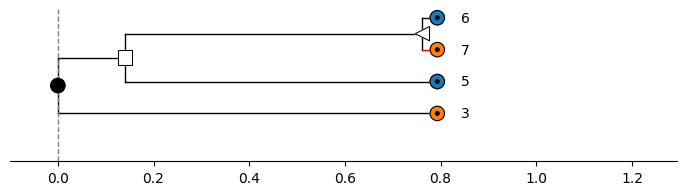

In [3]:
seed = random.randint(0,100000)
print(seed)
speciesTree, geneTree = generateTree(seed=48740 ,nSpecies=2)
# 2 Spezies, 3 leafs: seed = 76935
# 2 Spezies, 4 leafs: seed 48740
# 2 Spezies, 4 leafs: seed 43

species_colors, gene_colors = assign_colors(speciesTree, geneTree)

# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

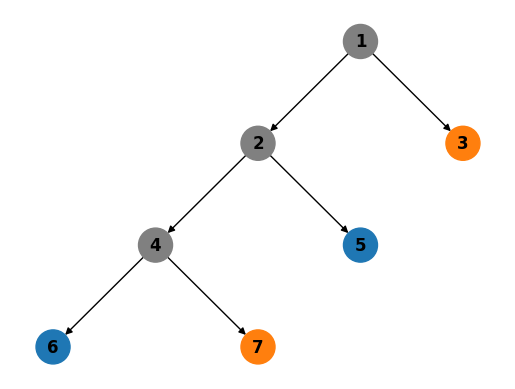

In [4]:
# convert to networkx
Tree = convert_to_nx(geneTree)
visualize_network(Tree)

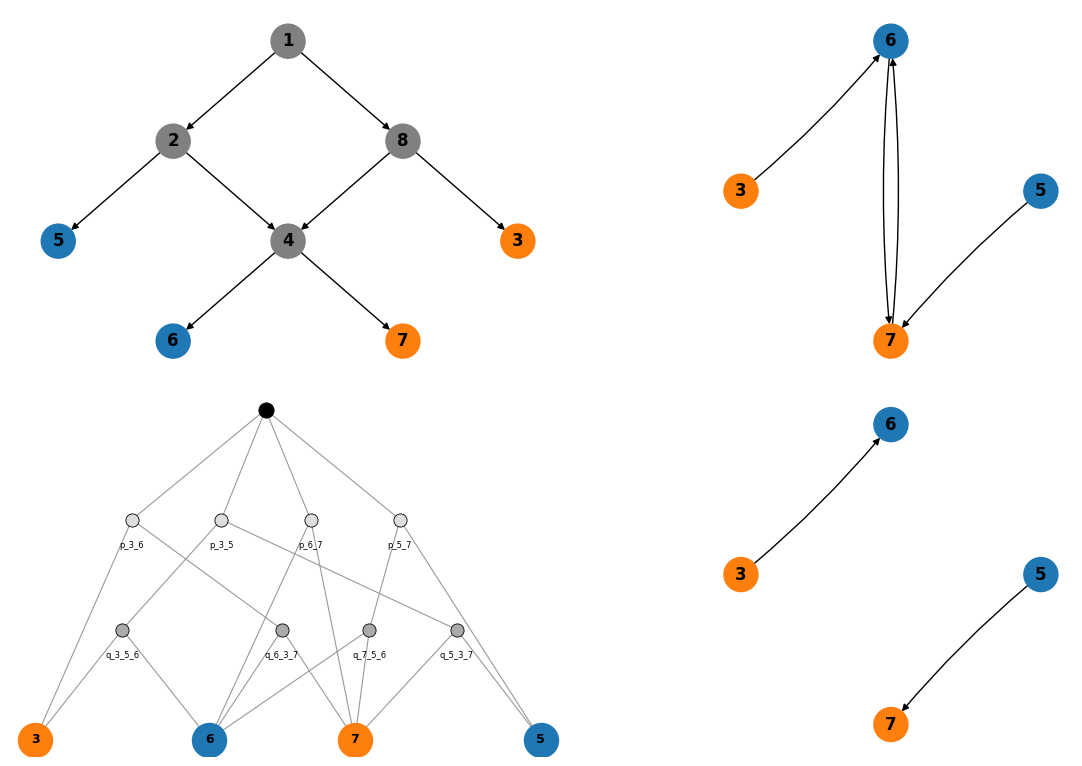

In [5]:
#########################################################################
# Gegenbeispiel für "strong BMG lässt sich immer durch BCEA darstellen" #
#########################################################################


# network = copy.copy(Tree)
# seed = random.randint(0,100000)
# # 56464 gibt uns das untere Netz
# print(seed)
network = insertHybrid(Tree,i = 1, seed = 56464)

mode = 'strong'
BMG = bmg(network, mode)
BC = BCEA3(BMG, mode)
BMGBC = bmg(BC, mode)

if not nx.utils.graphs_equal(BMG, BMGBC):
    fig, axes = plt.subplots(2, 2, figsize = (12,8))

    visualize_network(network, ax = axes[0,0])
    visualize_bmg(BMG, ax=axes[0,1])

    visualize_easyBCN(BC, ax = axes [1,0])
    visualize_bmg(BMGBC, ax=axes[1,1])

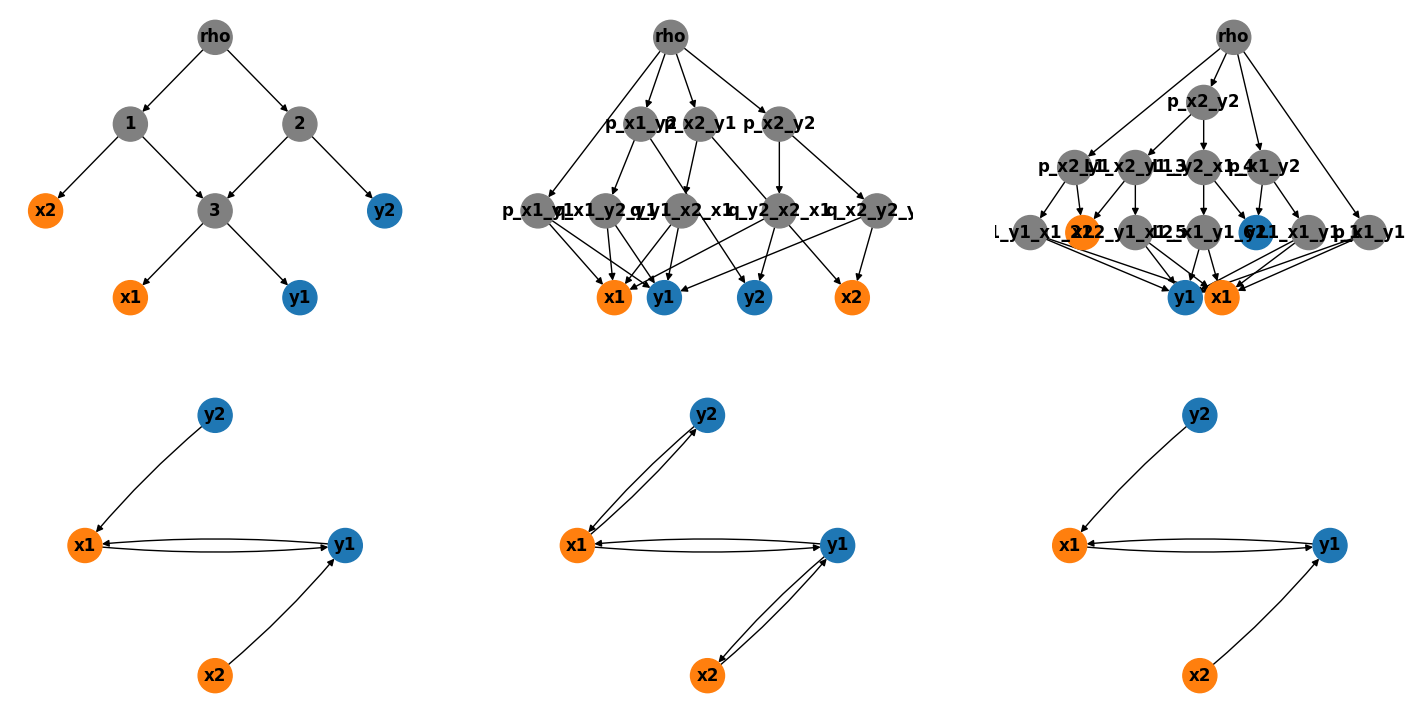

In [6]:
#########################################################################
# Beispiel, wann weak kaputt geht #
#########################################################################


mode = 'weak'

Netz = nx.DiGraph()
Netz.add_node('rho')
Netz.add_node('1')
Netz.add_node('2')
Netz.add_node('3')
Netz.add_node('x1', color = 'red')
Netz.add_node('x2', color = 'red')
Netz.add_node('y1', color = 'blue')
Netz.add_node('y2', color = 'blue')

Netz.add_edges_from([('rho','1'),('rho','2'),('1','3'),('2','3'),('1','x2'),('3','x1'),('3','y1'),('2','y2')])


BMG = bmg(Netz, mode)
BC = BCEA3(BMG, mode)
BMGBC = bmg(BC, mode)

MLBC = BCEA4(BMG)
BMGMLBC = bmg(MLBC, mode)

fig, axes = plt.subplots(2, 3, figsize = (18,9))

visualize_network(Netz, ax= axes[0,0])
visualize_bmg(BMG, ax= axes[1,0])

visualize_network(BC, ax= axes[0,1])
visualize_bmg(BMGBC, ax= axes[1,1])

visualize_network(MLBC, ax= axes[0,2])
visualize_bmg(BMGMLBC, ax= axes[1,2])

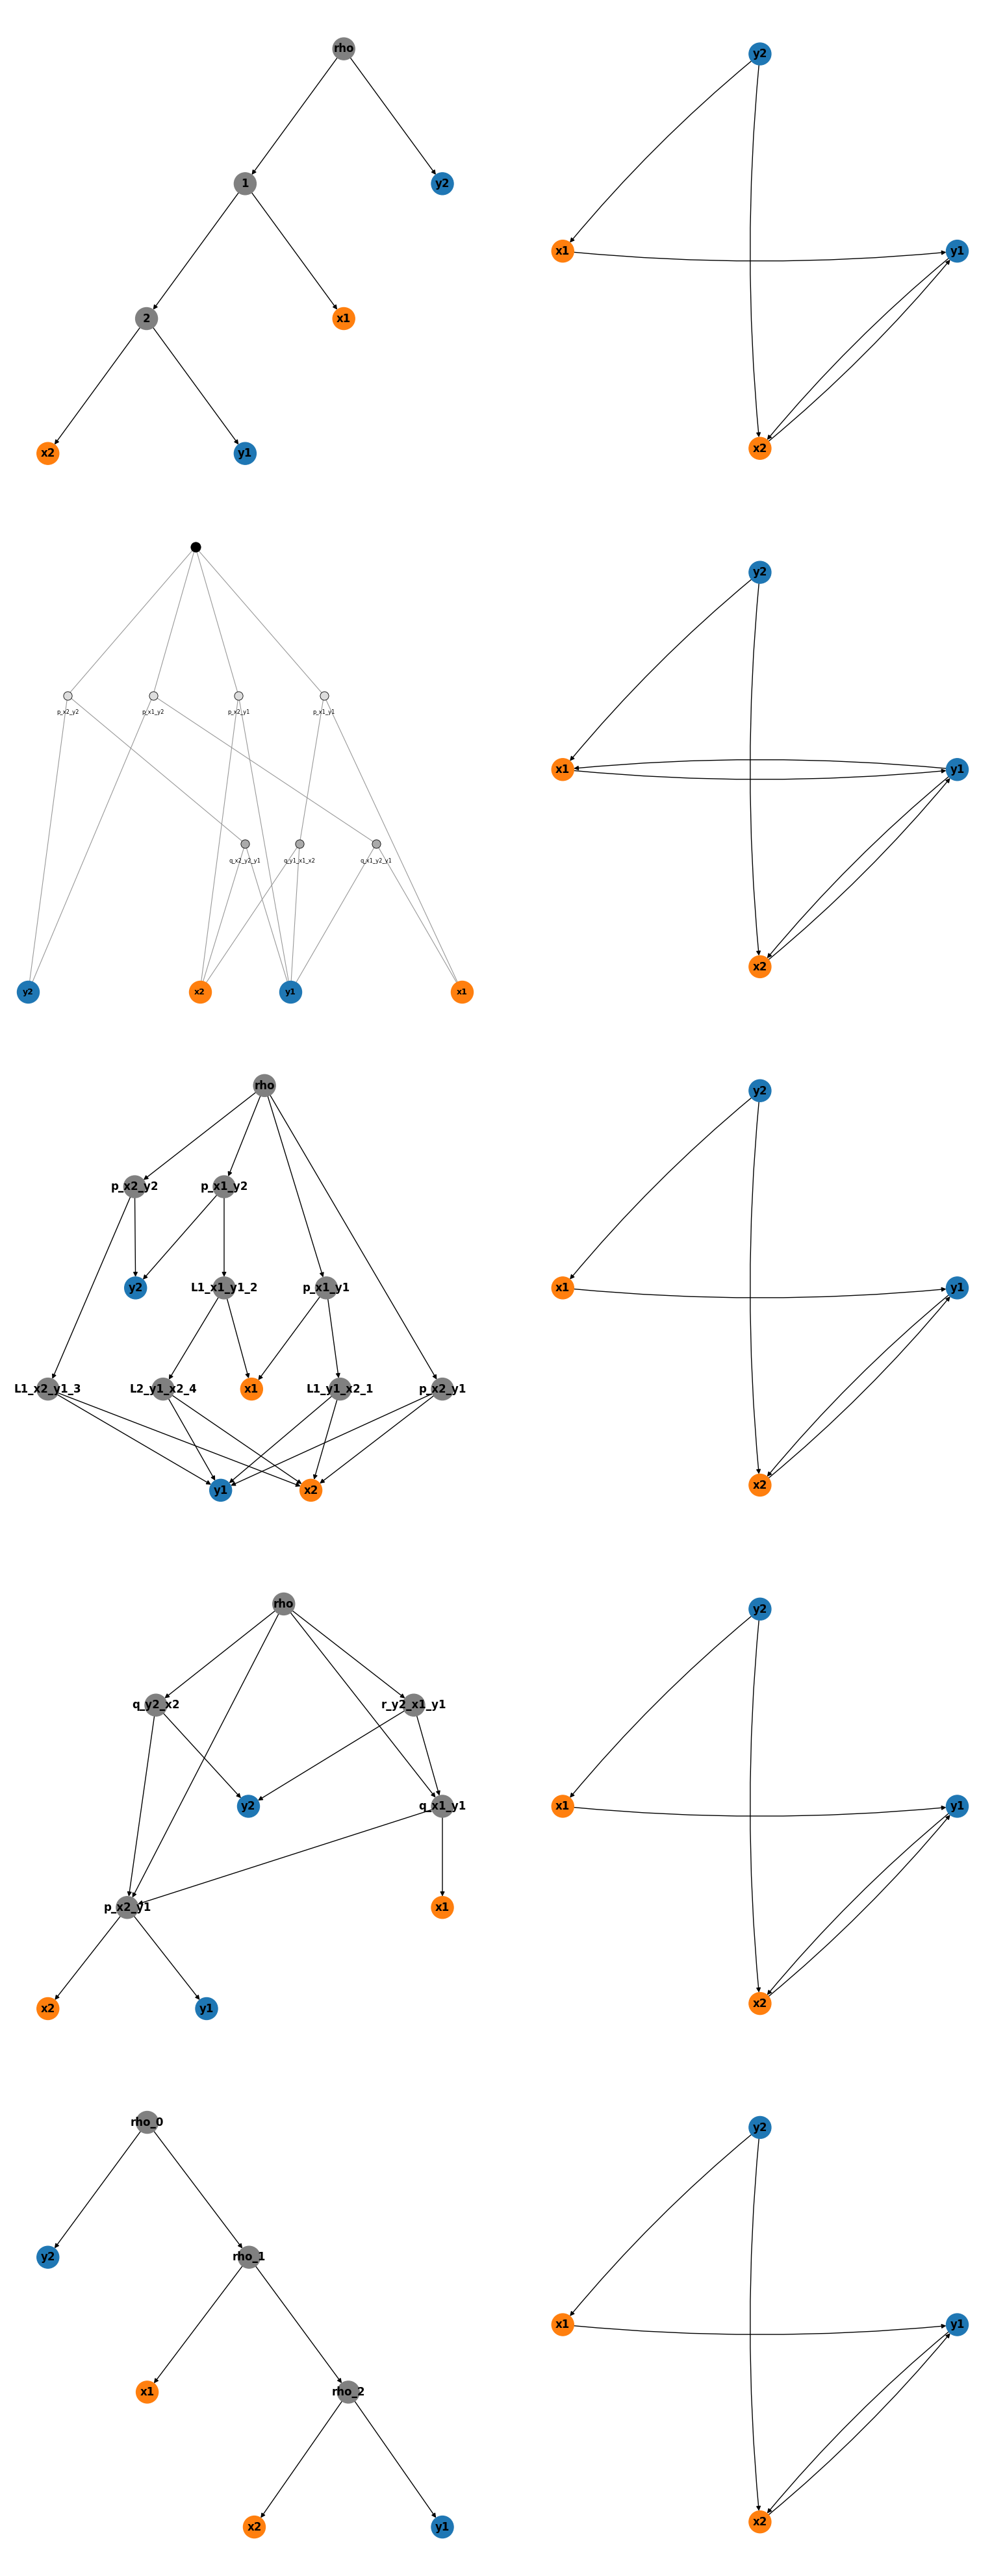

In [16]:
#########################################################################
#  Beispiel, wann weak kaputt geht  #
#########################################################################

mode = 'weak'

Netz = nx.DiGraph()
Netz.add_node('rho')
Netz.add_node('1')
Netz.add_node('2')
# Netz.add_node('3')
Netz.add_node('x1', color = 'red')
Netz.add_node('x2', color = 'red')
Netz.add_node('y1', color = 'blue')
Netz.add_node('y2', color = 'blue')

Netz.add_edges_from([('rho','1'),('1','2'),('1','x1'),('2','x2'),('2','y1'),('rho','y2')])

# visualize_network(Netz)

BMG = bmg(Netz, mode)
BC = BCEA3(BMG, mode)
BMGBC = bmg(BC, mode)

MLBC = BCEA4(BMG)
BMGMLBC = bmg(MLBC, mode)

RBC = BICcherry_reverse(BMG)
BMGRBC = bmg(RBC,mode)

SRBC = BICcherry_reverse(BMG, simplify= True)
BMGSRBC = bmg(SRBC,mode)

fig, axes = plt.subplots(5, 2, figsize = (16,40))

visualize_network(Netz, ax= axes[0,0])
visualize_bmg(BMG, ax= axes[0,1])

visualize_easyBCN(BC, ax= axes[1,0])
visualize_bmg(BMGBC, ax= axes[1,1])

visualize_network(MLBC, ax= axes[2,0])
visualize_bmg(BMGMLBC, ax= axes[2,1])

visualize_network(RBC, ax= axes[3,0])
visualize_bmg(BMGRBC, ax= axes[3,1])

visualize_network(SRBC, ax= axes[4,0])
visualize_bmg(BMGSRBC, ax= axes[4,1])



False


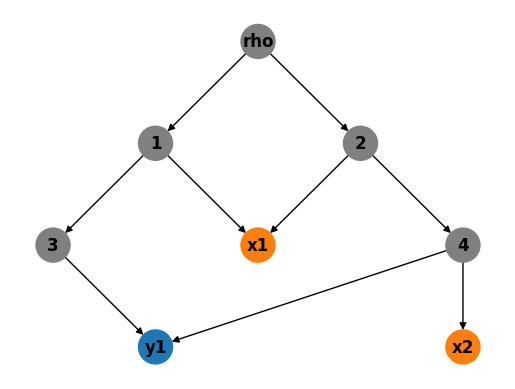

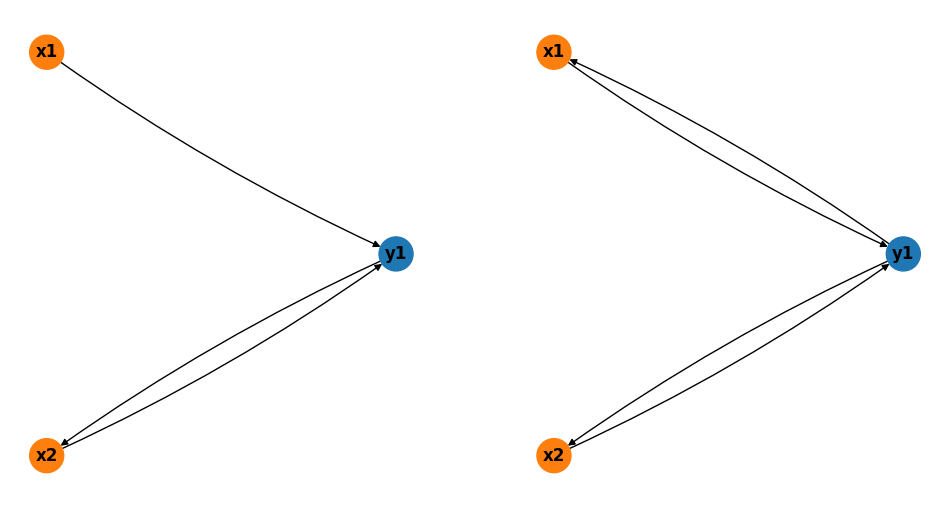

In [8]:
##################
# weak != strong #
##################

Netz = nx.DiGraph()
Netz.add_node('rho')
Netz.add_node('1')
Netz.add_node('2')
Netz.add_node('3')
Netz.add_node('4')
Netz.add_node('x1', color = 'red')
Netz.add_node('x2', color = 'red')
Netz.add_node('y1', color = 'blue')

Netz.add_edges_from([('rho','1'),('rho','2'),('1','3'),('2','4'),('1','x1'),('2','x1'),('3','y1'),('4','x2'),('4','y1')])

visualize_network(Netz)

SBMG = bmg(Netz, 'strong')
WBMG = bmg(Netz, 'weak')

print(nx.utils.graphs_equal(SBMG, WBMG))

fig, axes = plt.subplots(1, 2, figsize = (12,8))

visualize_bmg(SBMG, ax = axes[0])
visualize_bmg(WBMG, ax=axes[1])



False
True


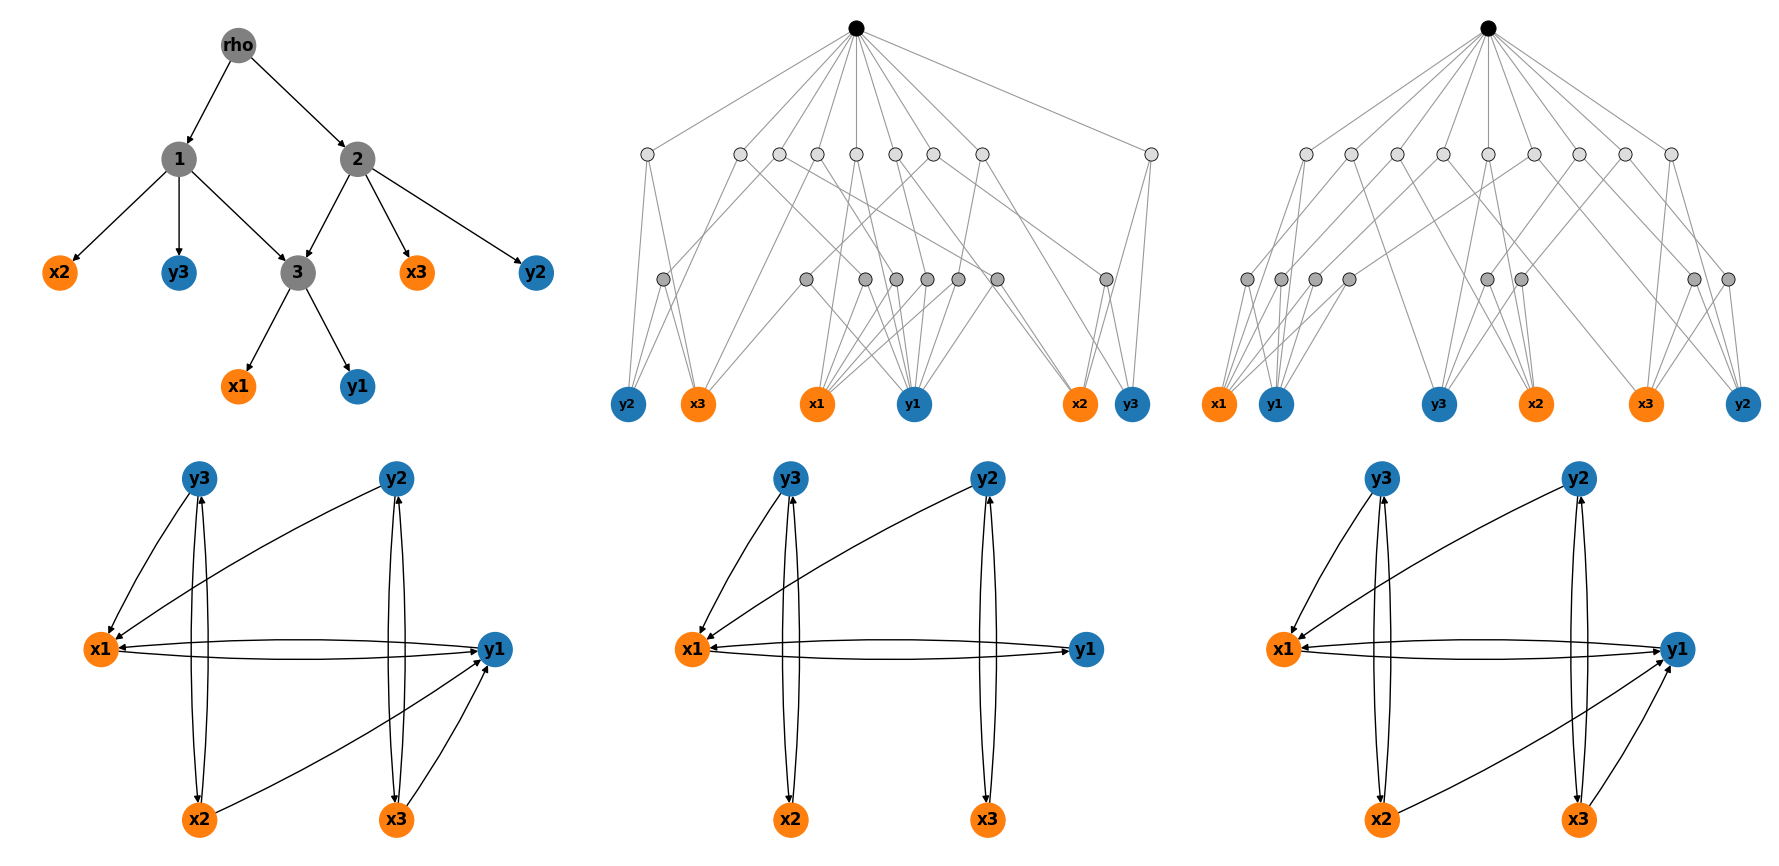

In [9]:
####################################################################
# generieren von Bäumen, bei denen sich die neuen Kriterien lohnen #
####################################################################

mode = 'strong'

Netz = nx.DiGraph()
Netz.add_node('rho')
Netz.add_node('1')
Netz.add_node('2')
Netz.add_node('3')
Netz.add_node('x1', color = 'red')
Netz.add_node('x2', color = 'red')
Netz.add_node('x3', color = 'red')
Netz.add_node('y1', color = 'blue')
Netz.add_node('y2', color = 'blue')
Netz.add_node('y3', color = 'blue')

Netz.add_edges_from([('rho','1'),('rho','2')])
Netz.add_edges_from([('1','3'),('1','x2'),('1','y3')])
Netz.add_edges_from([('2','3'),('2','y2'),('2','x3')])
Netz.add_edges_from([('3','x1'),('3','y1')])


BMG = bmg(Netz, mode)

# BC1 = BCEA1(BMG)
# BMGBC1 = bmg(BC1,mode)

BC2 = BCEA2(BMG)
BMGBC2 = bmg(BC2,mode)

BC3 = BCEA3(BMG, mode)
BMGBC3 = bmg(BC3, mode)


# print(nx.utils.graphs_equal(BMG, BMGBC1))
print(nx.utils.graphs_equal(BMG, BMGBC2))
print(nx.utils.graphs_equal(BMG, BMGBC3))

fig, axes = plt.subplots(2, 3, figsize = (18,9))

visualize_network(Netz, ax= axes[0,0])
visualize_bmg(BMG, ax= axes[1,0])

visualize_easyBCN(BC2, ax= axes[0,1], show_internal_labels= False)
visualize_bmg(BMGBC2, ax= axes[1,1])

# visualize_easyBCN(BC1, ax= axes[0,2], show_internal_labels= False)
# visualize_bmg(BMGBC1, ax= axes[1,2])

visualize_easyBCN(BC3, ax= axes[0,2], show_internal_labels= False)
visualize_bmg(BMGBC3, ax= axes[1,2])

True
False
False


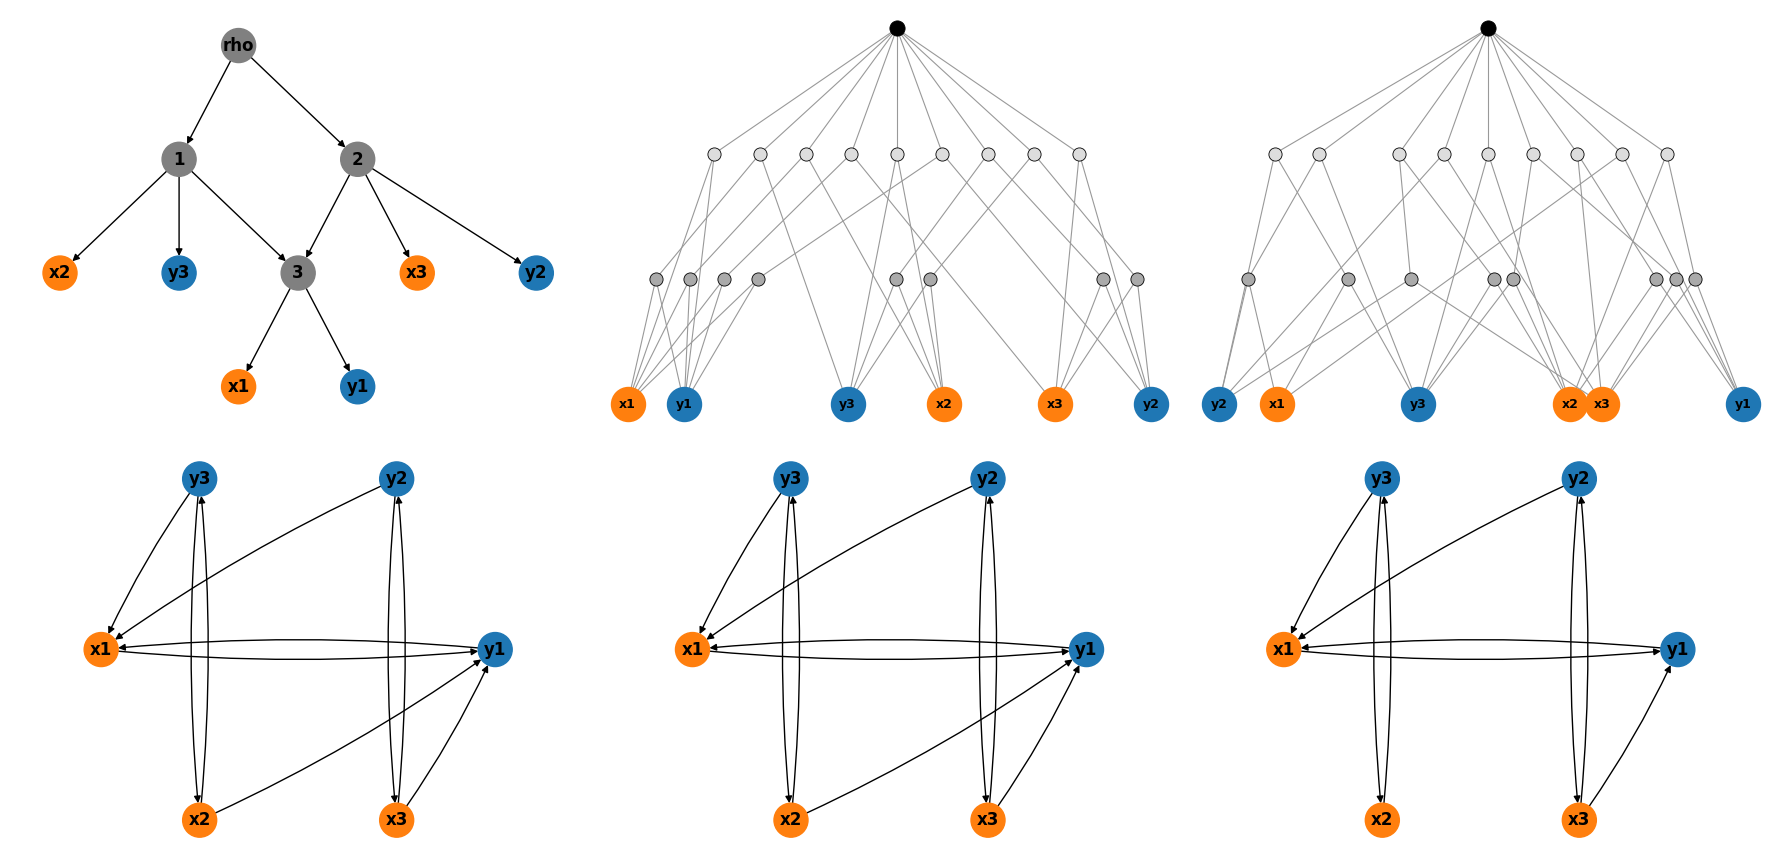

In [10]:
####################################################################
# generieren von Bäumen, bei denen sich die neuen Kriterien lohnen #
####################################################################

mode = 'strong'

Netz = nx.DiGraph()
Netz.add_node('rho')
Netz.add_node('1')
Netz.add_node('2')
Netz.add_node('3')
Netz.add_node('x1', color = 'red')
Netz.add_node('x2', color = 'red')
Netz.add_node('x3', color = 'red')
Netz.add_node('y1', color = 'blue')
Netz.add_node('y2', color = 'blue')
Netz.add_node('y3', color = 'blue')

Netz.add_edges_from([('rho','1'),('rho','2')])
Netz.add_edges_from([('1','3'),('1','x2'),('1','y3')])
Netz.add_edges_from([('2','3'),('2','y2'),('2','x3')])
Netz.add_edges_from([('3','x1'),('3','y1')])

BMG = bmg(Netz, mode)
BC1 = BCEA3(BMG, mode)
BMGBC1 = bmg(BC1, mode)

BC2 = BCEA1(BMG)
BMGBC2 = bmg(BC2, mode)

print(nx.utils.graphs_equal(BMG, BMGBC1))
print(nx.utils.graphs_equal(BMG, BMGBC2))
print(nx.utils.graphs_equal(BMGBC1, BMGBC2))

fig, axes = plt.subplots(2, 3, figsize = (18,9))

visualize_network(Netz, ax= axes[0,0])
visualize_bmg(BMG, ax= axes[1,0])

visualize_easyBCN(BC1, ax= axes[0,1], show_internal_labels= False)
visualize_bmg(BMGBC1, ax= axes[1,1])

visualize_easyBCN(BC2, ax= axes[0,2], show_internal_labels= False)
visualize_bmg(BMGBC2, ax= axes[1,2])

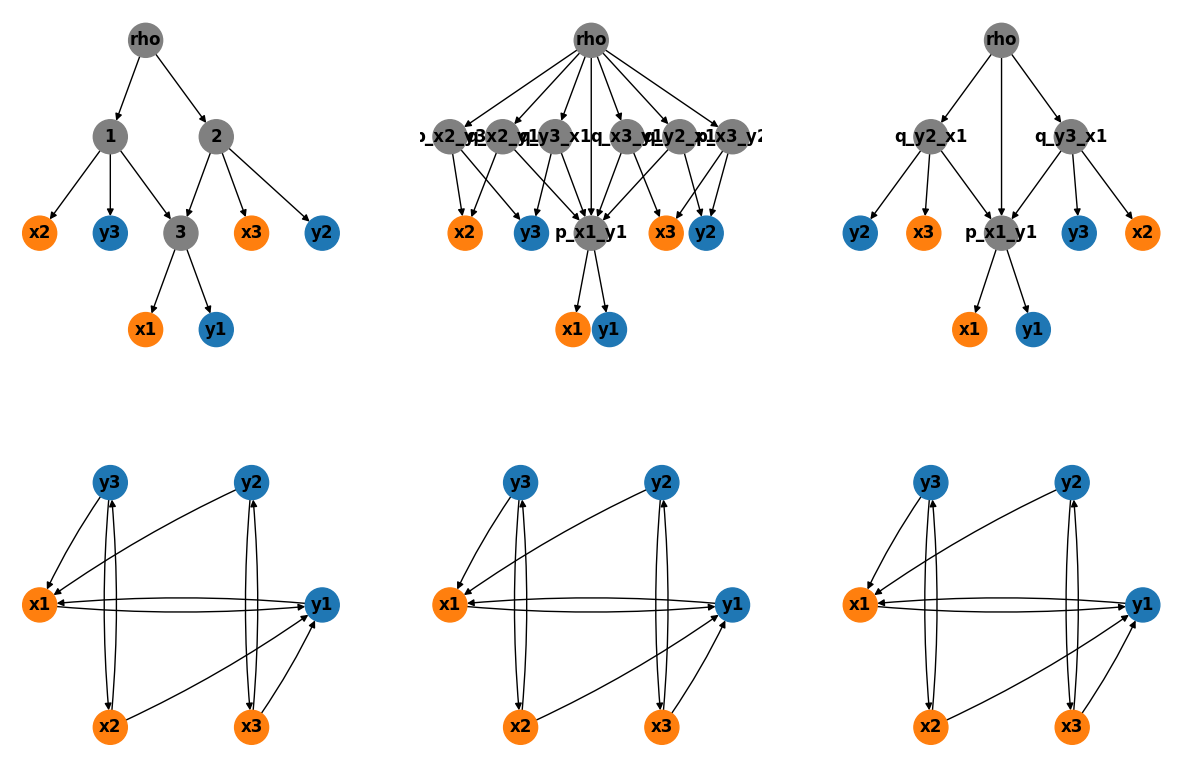

In [11]:
####################################################################
# generieren von Bäumen, bei denen sich die neuen Kriterien lohnen #
####################################################################

mode = 'strong'

Netz = nx.DiGraph()
Netz.add_node('rho')
Netz.add_node('1')
Netz.add_node('2')
Netz.add_node('3')
Netz.add_node('x1', color = 'red')
Netz.add_node('x2', color = 'red')
Netz.add_node('x3', color = 'red')
Netz.add_node('y1', color = 'blue')
Netz.add_node('y2', color = 'blue')
Netz.add_node('y3', color = 'blue')

Netz.add_edges_from([('rho','1'),('rho','2')])
Netz.add_edges_from([('1','3'),('1','x2'),('1','y3')])
Netz.add_edges_from([('2','3'),('2','y2'),('2','x3')])
Netz.add_edges_from([('3','x1'),('3','y1')])

BMG = bmg(Netz, mode)
BC1 = BCEA3(BMG, mode)
BMGBC1 = bmg(BC1, mode)

RBC_pre = BICcherry_reverse(BMG)
BMGRBC = bmg(RBC_pre, mode)

RBC = RBC_pre.copy()
# print(nx.utils.graphs_equal(BMG, BMGBC1))
# print(nx.utils.graphs_equal(BMG, BMGBC2))
# print(nx.utils.graphs_equal(BMGBC1, BMGBC2))

RBC = contract_nodes(RBC)


fig, axes = plt.subplots(2,3, figsize = (15,10))

visualize_network(Netz, ax = axes[0,0])
visualize_bmg(bmg(Netz,'weak'), ax= axes[1,0])

visualize_network(RBC_pre, ax = axes[0,1])
visualize_bmg(BMGRBC, ax= axes[1,1])

visualize_network(RBC, ax = axes[0,2])
visualize_bmg(bmg(RBC,'weak'), ax= axes[1,2])




In [12]:
speciesTree, geneTree = generateTree(nSpecies=4)
Tree = convert_to_nx(geneTree)

mode = 'weak'

Netz = insertHybrid(Tree,random.choice((1,10)))

BMG = bmg(Netz, mode)
RBC = BICcherry_reverse(BMG)
BMGRBC = bmg(RBC, mode)

Network_after_greedy = greedy_search(RBC.copy())

network_after_contraction = contract_nodes(Network_after_greedy.copy())



simplifying step 1/100
simplifying step 2/100
simplifying step 3/100
simplifying step 4/100
simplifying step 5/100
simplifying step 6/100
simplifying step 7/100
simplifying step 8/100
simplifying step 9/100
simplifying step 10/100
simplifying step 11/100
simplifying step 12/100
simplifying step 13/100
simplifying step 14/100
simplifying step 15/100
simplifying step 16/100
simplifying step 17/100
simplifying step 18/100
simplifying step 19/100
simplifying step 20/100
simplifying step 21/100
simplifying step 22/100
simplifying step 23/100
simplifying step 24/100
simplifying step 25/100
simplifying step 26/100
simplifying step 27/100
simplifying step 28/100
simplifying step 29/100
simplifying step 30/100
simplifying step 31/100
simplifying step 32/100
simplifying step 33/100


KeyError: 'color'

all BMGs equal? True


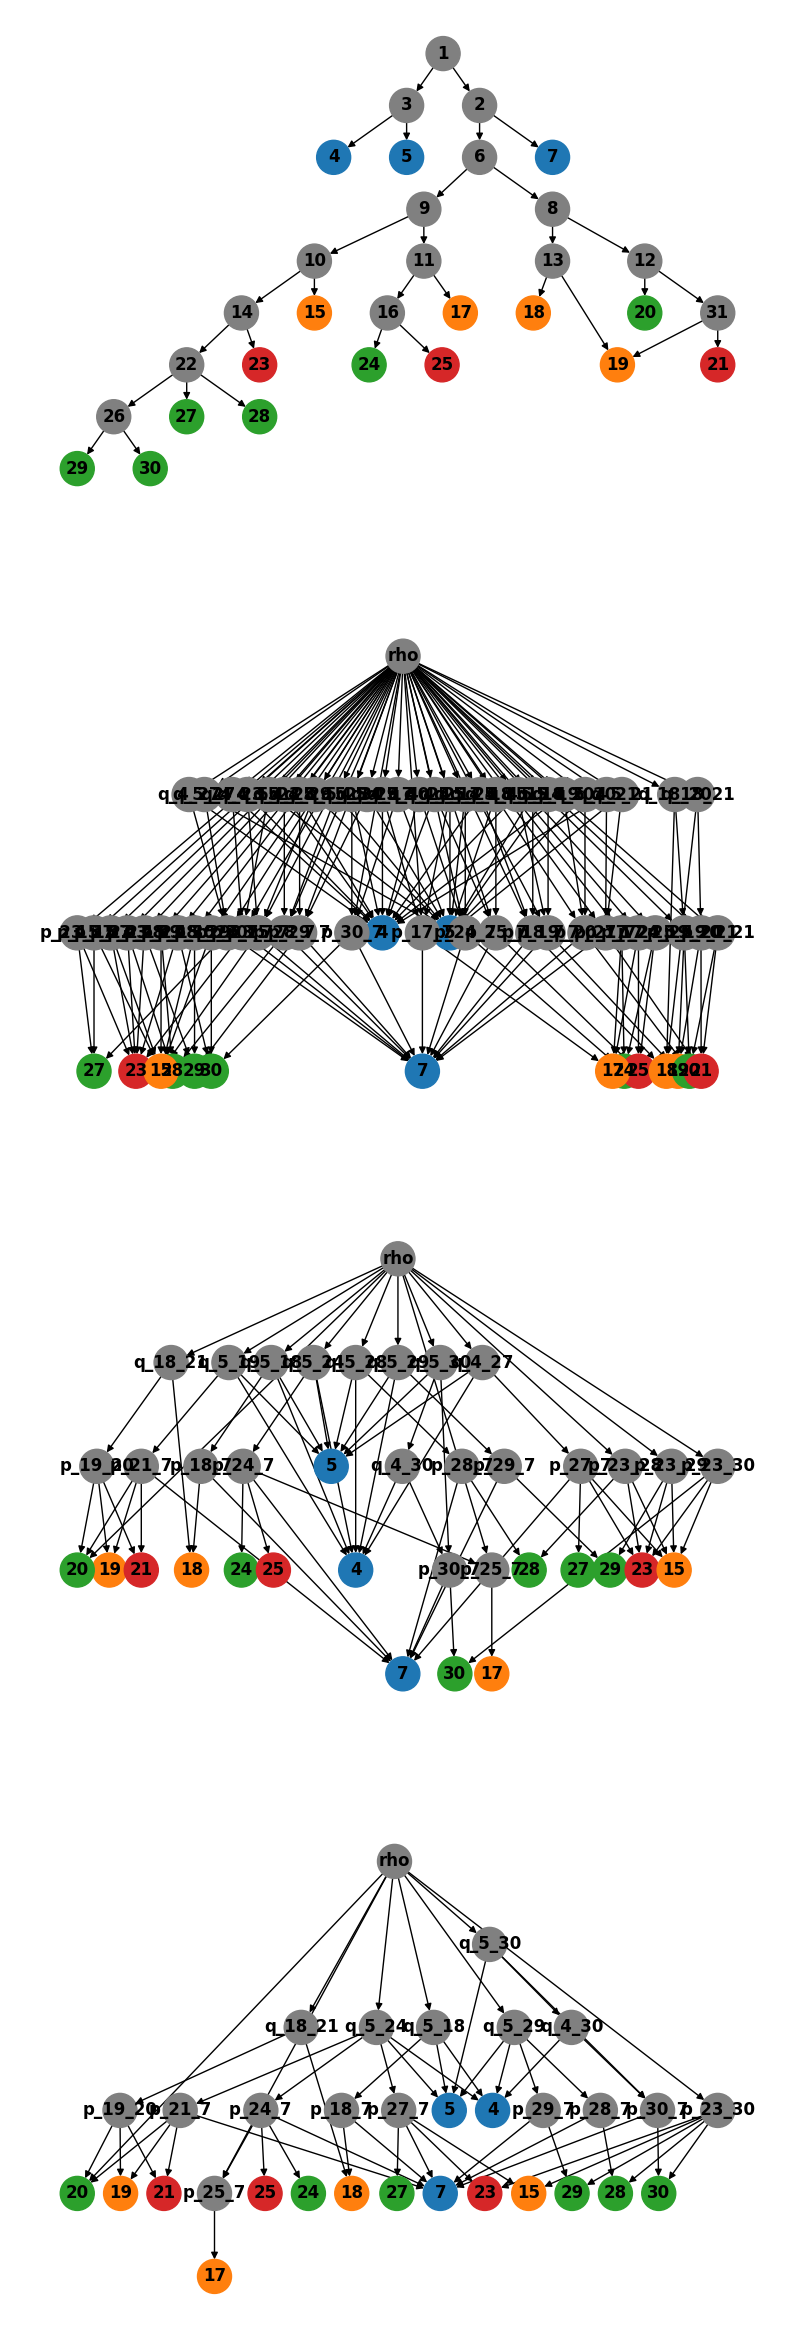

In [ ]:
check1 = nx.utils.graphs_equal(BMG, BMGRBC)
check2 = nx.utils.graphs_equal(BMG, bmg(Network_after_greedy,'weak'))
check3 = nx.utils.graphs_equal(BMG, bmg(network_after_contraction,'weak'))


print('all BMGs equal?',(check1 and check2 and check3))


fig, axes = plt.subplots(4, 1, figsize = (10,30))

visualize_network(Netz, ax= axes[0])
# visualize_bmg(bmg(Netz,'weak'), ax= axes[0,1])

visualize_network(RBC, ax= axes[1])
# visualize_bmg(bmg(RBC,'weak'), ax= axes[1,1])

visualize_network(Network_after_greedy, ax= axes[2])
# visualize_bmg(bmg(Network_after_greedy,'weak'), ax= axes[2,1])

visualize_network(network_after_contraction, ax= axes[3])
# visualize_bmg(bmg(network_after_contraction,'weak'), ax= axes[3,1])